In [17]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import sys, os
from astropy.table import Table
from astropy.io import fits
import matplotlib.pyplot as plt
import tqdm


In [18]:
def get_sdss_file_ids(path, snr_lowe_edge, snr_upper_edge=np.inf):
    """ Get a list of (PLATE, MJD, FIBERID) from the SDSS BOSS Lyman alpha forest catalogue
      of spectra with S/N in given range.

    Args:
        path (string): path to the catalogue file
        snr_lowe_edge (float): lower filter for the signa to noise ratio of the spectra
        snr_upper_edge (float, optional): upper filter for the signa to noise ratio of the spectra

    Returns:
        list: list of (PLATE, MJD, FIBERID) tuples for spectra in the SDSS BOSS Lyman alpha forest catalogue
    """
    lya_cat = Table.read(path)
    pmf_list = []

    for row in lya_cat:
        if row["SNR"] > snr_lowe_edge and row["SNR"] < snr_upper_edge:
            pmf_list.append((row["PLATE"], row["MJD"], row["FIBERID"]))

    return pmf_list


def get_sdss_spectra(resid_file_path, pmf_list, speclya_basepath="/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/BOSSLyaDR9_spectra", min_wavelength=3600.0, max_wavelength=3950.0, return_pmf_list=False):
    """ Calculates corrected SDSS BOSS Lyman alpha forest spectra from given pmf list and paths within the given
    wavelength range. Note: If pmf_list has thousands of entries, this function might take a couple of minutes to
    run, as it has to open a data file for every spectrum.

    Args:
        resid_file_path (string): path to the resid file
        pmf_list (list): list of (PLATE, MJD, FIBERID) tuples. These set which spectra to load from the survey
        speclya_basepath (str, optional): Basepath where the SDSS Survey data is. Defaults to "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/BOSSLyaDR9_spectra".
        min_wavelength (float, optional): Lower cutoff for the wavelengths. Defaults to 3600.0.
        max_wavelength (float, optional): Upper cutoff for the wavelengths. Defaults to 3950.0.
        return_pmf_list (bool, optional): Whether to return the pmf list of the used spectra. This can be used to make a custom catalogue

    Returns:
        snrs (list): List of np.arrays containing the SNR per pixel for every spectrum
        wavelengths_boss_specs (list): List of np.arrays of wavelengths for every spectrum 
        fluxes_boss_specs (list): List of np.arrays of fluxes for every spectrum
    """
    # -------- Read RESID File --------
    resid_file = resid_file_path
    resid = []
    resid_lam = []

    with open(resid_file) as rfile:
        reader = csv.reader(rfile, delimiter=" ")
        for i, row in enumerate(reader):
            if i != 0:
                resid.append(float(row[-1]))
                resid_lam.append(float(row[1]))

    resid_lam_file = np.array(resid_lam)
    resid_file = np.array(resid)
    # --------------------------------

    wavelengths_boss_specs = []
    fluxes_boss_specs = []
    snrs = []
    pmf_return_list = []

    for plate, mjd, fiber in tqdm.tqdm(pmf_list):
        # -------- Read Spectra file --------
        fiber_str = f"{fiber:04d}"
        filename = f"speclya-{plate}-{mjd}-{fiber_str}.fits"
        file_path = f"{speclya_basepath}/{plate}/" + filename

        with fits.open(file_path) as hdul:
            data = hdul[1].data

            loglam   = data["LOGLAM"]
            flux     = data["FLUX"]
            ivar     = data["IVAR"]
            cont     = data["CONT"]
            dla_corr = data["DLA_CORR"]
            mask_comb = data["MASK_COMB"]
            dla_corr = data["DLA_CORR"]
            noise_corr = data["NOISE_CORR"]

        # -------- Select correct range for Resids --------
        """ # This was way too slow
        i0 = np.where(np.isclose(resid_lam_file, loglam[0]))[0][0]
        i1 = np.where(np.isclose(resid_lam_file, loglam[-1]))[0][0] + 1
        """
        # this is much faster, as the resid file is sorted and has a constant step size
        step = 1e-4  # standard BOSS/SDSS log-wavelength pixel size
        i0 = int(round((loglam[0] - resid_lam_file[0]) / step))
        i1 = i0 + len(loglam)

        resid = resid_file[i0:i1]

        # -------------------------------------------------

        # Convert wavelengths to angstroms
        wavelength = 10**loglam

        # SDSS-recommended pixel mask
        good_pixel = (
            (mask_comb == 0) &
            (ivar > 0)
        )

        # Initialize F, SIGMA_F with NaNs
        F = np.full_like(flux, np.nan)
        SIGMA_F = np.full_like(flux, np.nan)

        # Compute F and SIGMA_F ONLY for good pixels
        F[good_pixel] = (flux[good_pixel] * dla_corr[good_pixel] / ((cont[good_pixel] * resid[good_pixel])))
        SIGMA_F[good_pixel] = np.sqrt(ivar[good_pixel] * resid[good_pixel]**2 * noise_corr[good_pixel]**2 * cont[good_pixel]**2 / dla_corr[good_pixel]**2)

        # -------- Select Lyα forest region --------
        forest_mask = (
            (wavelength >= min_wavelength) &
            (wavelength <= max_wavelength)
        )

        wave_sel = wavelength[forest_mask]
        F_sel    = F[forest_mask]
        Sigma_F_sel = SIGMA_F[forest_mask]

        # -------- Filter out spectra with Nans and Infs --------

        if np.any(np.isnan(F_sel)) or (not np.all(np.isfinite(F_sel))):
            continue

        # -------------------------------------------------------
        
        snrs.append(Sigma_F_sel)
        wavelengths_boss_specs.append(wave_sel)
        fluxes_boss_specs.append(F_sel)
        if return_pmf_list:
            pmf_return_list.append((plate, mjd, fiber))

    if return_pmf_list:
        return snrs, wavelengths_boss_specs, fluxes_boss_specs, pmf_return_list
    else:
        return np.array(snrs), np.array(wavelengths_boss_specs), np.array(fluxes_boss_specs)

In [19]:
cat_file = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/SDSS_support_files/BOSSLyaDR9_cat.fits"

lya_cat = Table.read(cat_file)
redshifts_list = []
pmf_list = []

for row in lya_cat:
    redshifts_list.append(row['Z_VI'])
    pmf_list.append((row["PLATE"], row["MJD"], row["FIBERID"]))

(array([   0.,    0.,    0., 2882., 3903., 4511., 4163., 4116., 3690.,
        3211., 2851., 2682., 2345., 2009., 1656., 1365., 1326., 1306.,
        1181., 1201., 1117., 1076.,  980.,  980.,  820.,  718.,  602.,
         428.,  288.,  220.,  189.,  238.,  269.,  282.,  262.,  263.,
         218.,  174.,  151.,  136.,  100.,   78.,   76.,   47.,   45.,
          39.,   25.,   30.,   33.,   20.,   20.,   16.,   18.,   23.,
          14.,   20.,   10.,   12.,    7.,    7.]),
 array([2.        , 2.04999995, 2.0999999 , 2.1500001 , 2.20000005,
        2.25      , 2.29999995, 2.3499999 , 2.4000001 , 2.45000005,
        2.5       , 2.54999995, 2.5999999 , 2.6500001 , 2.70000005,
        2.75      , 2.79999995, 2.8499999 , 2.9000001 , 2.95000005,
        3.        , 3.04999995, 3.0999999 , 3.1500001 , 3.20000005,
        3.25      , 3.29999995, 3.3499999 , 3.4000001 , 3.45000005,
        3.5       , 3.54999995, 3.5999999 , 3.6500001 , 3.70000005,
        3.75      , 3.79999995, 3.8499999 , 3.

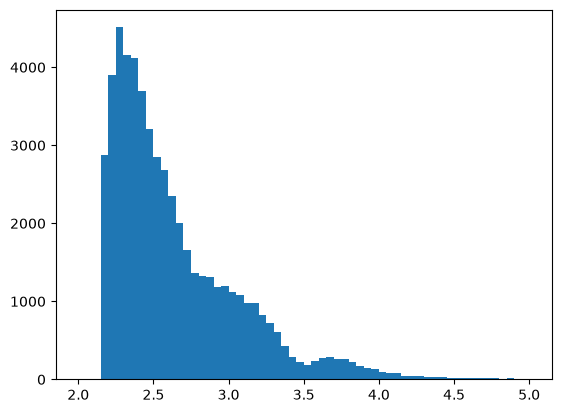

In [4]:
plt.hist(redshifts_list, bins=60, range=(2.0, 5.0))

In [21]:
resid_file = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/SDSS_support_files/residcorr_v5_4_45.dat"

snrs, wavelengths_boss_specs, fluxes_boss_specs, pmfs_used = get_sdss_spectra(resid_file, pmf_list[:1], return_pmf_list=True)

  0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_3386340/4230865450.py:108: RuntimeWarning: divide by zero encountered in divide
  F[good_pixel] = (flux[good_pixel] * dla_corr[good_pixel] / ((cont[good_pixel] * resid[good_pixel])))
100%|██████████| 1/1 [00:00<00:00, 11.23it/s]


In [6]:
print(redshifts_list[0])

peak = 1215.67 * (1 + redshifts_list[0])

2.163


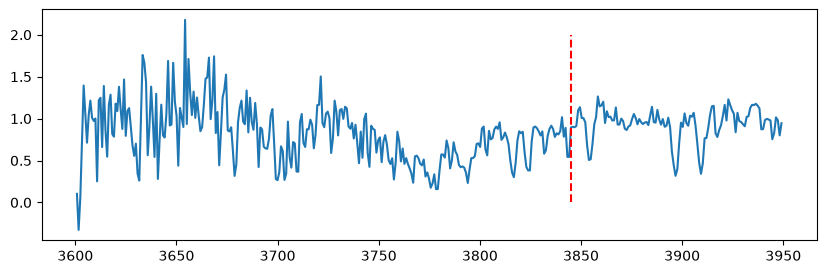

In [ ]:
fig = plt.figure(figsize=(10, 3))

plt.plot(wavelengths_boss_specs[0], fluxes_boss_specs[0])

plt.vlines(peak, ymin=0, ymax=2, color='r', linestyle='--', label='Lyα peak')

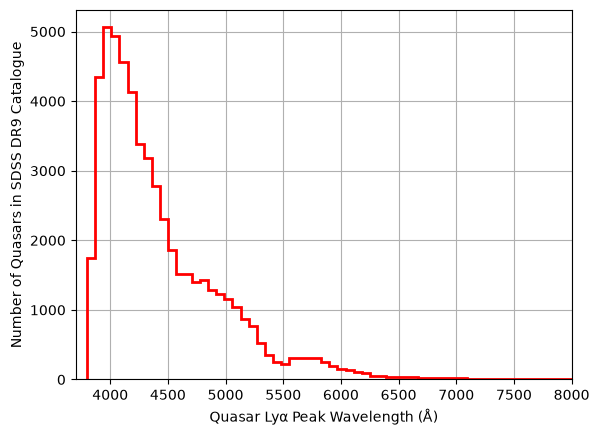

In [8]:
peaks = 1215.67 * (np.array(redshifts_list) + 1)

plt.hist(peaks, bins=60, histtype='step', linewidth=2, color='r', range=(3800, 8000))
plt.xlabel('Quasar Lyα Peak Wavelength (Å)')
plt.ylabel('Number of Quasars in SDSS DR9 Catalogue')
plt.xlim(3700, 8000)
plt.grid()

plt.savefig('plots/lyman_alpha_peak_hist.pdf', format="pdf")
plt.show()

In [9]:
# for higher redshifts the ly beta line gets shifted into the lower wavelength range. Thus this creates a upper bound on what redshifts we can include for a given lower wavelngth edge. -QUESTION: is lyman beta even a probelm? It should also be in the reals spectra, right? Just need to be careful when combining the spectra then i guess and add the absorptions?

lower_edge =3600

upper_ly_beta_bound = 1215.67 * (lower_edge/1025.7220)

print("Upper bound in A", upper_ly_beta_bound)
print("Upper bound in z", (upper_ly_beta_bound/1215.67) - 1)

Upper bound in A 4266.664846810345
Upper bound in z 2.509722907376463


In [10]:
snrs, wavelengths_boss_specs, fluxes_boss_specs, pmfs_used = get_sdss_spectra(resid_file, pmf_list[:100], return_pmf_list=True)

np_specs = []
ivar_snrs = []
pmfs_used_filtered = []
wavelengths_filtered = []
for i, spec in enumerate(fluxes_boss_specs):
    if len(spec) == 402:
        np_specs.append(np.append(spec, spec[-1]))
        ivar_snrs.append(np.append(snrs[i], snrs[i][-1]))
        pmfs_used_filtered.append(pmfs_used[i])
        wavelengths_filtered.append(np.append(wavelengths_boss_specs[i], wavelengths_boss_specs[0][-1])) # just gable that the first spectrum has the same wavelength grid as all the others, which i think is true for the SDSS spectra

specs = np.array(np_specs)
snrs_pp = np.array(ivar_snrs)
pmfs_specs = np.array(pmfs_used_filtered)
wavelengths_specs = np.array(wavelengths_filtered)

print(specs.shape)
print(snrs_pp.shape)
print(pmfs_specs.shape)
print(wavelengths_specs.shape)

np.savez_compressed("test_file.npz", specs=specs, wavelengths=wavelengths_specs, snrs=snrs_pp, pmfs=pmfs_specs)

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_2841344/1493532922.py:102: RuntimeWarning: divide by zero encountered in divide
  F[good_pixel] = (flux[good_pixel] * dla_corr[good_pixel] / ((cont[good_pixel] * resid[good_pixel])))
100%|██████████| 100/100 [00:09<00:00, 10.78it/s]

(42, 403)
(42, 403)
(42, 3)
(42, 403)


In [11]:
data = np.load("sdss_compressed.npz", allow_pickle=True)

fluxes = data['specs']
wavelengths = data['wavelengths']
snrs = data['snrs']
pmfs = data['pmfs']

print(pmfs.shape)
print(fluxes.shape)


(24145, 3)
(24145, 403)


In [12]:
z_sdss = np.array(redshifts_list)
pmf_sdss = np.array(pmf_list)

pmf_to_z = {tuple(pmf): z for pmf, z in zip(pmf_sdss, z_sdss)}

z_used = np.array([pmf_to_z[tuple(pmf)] for pmf in pmfs])

print(z_used.shape)

(24145,)


In [66]:
print(wavelengths)

[[3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]
 [3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]
 [3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]
 ...
 [3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]
 [3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]
 [3600.8088 3601.6372 3602.4678 ... 3948.208  3949.1162 3949.1162]]


In [15]:
redshifts = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 3.0]

mean_fluxes = []
mean_fluxes_err = []

wavelength_grid = wavelengths[0]

for z_here in redshifts:
    z_mask = (z_used > z_here + 0.05)
    fluxes_here = fluxes[z_mask]
    wavelengths_here = wavelengths[z_mask]

    wavelength_upper = 1215.67 * (1 + z_here + 0.5)
    wavelength_lower = 1215.67 * (1 + z_here)

    wavelength_mask = (
        (wavelength_grid >= wavelength_lower) &
        (wavelength_grid <= wavelength_upper)
    )

    fluxes_selected = fluxes_here[:, wavelength_mask]

    print(fluxes_selected.shape)

    mean_fluxes.append(fluxes_selected.mean(axis=1).mean())
    mean_fluxes_err.append(fluxes_selected.mean(axis=1).std())


(24145, 347)
(24145, 205)
(17698, 67)
(9798, 0)
(2705, 0)
(0, 0)
(0, 0)
(0, 0)
(0, 0)
(0, 0)


/tmp/ipykernel_2841344/1056328537.py:25: RuntimeWarning: Mean of empty slice
  mean_fluxes.append(fluxes_selected.mean(axis=1).mean())
/home/hd/hd_hd/hd_pv276/.local/envs/myenv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_2841344/1056328537.py:26: RuntimeWarning: Mean of empty slice
  mean_fluxes_err.append(fluxes_selected.mean(axis=1).std())
/home/hd/hd_hd/hd_pv276/.local/envs/myenv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/hd/hd_hd/hd_pv276/.local/envs/myenv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/hd/hd_hd/hd_pv276/.local/envs/myenv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide


In [18]:
print(mean_fluxes)
print(mean_fluxes_err)

[np.float32(0.95869124), np.float32(0.9078099), np.float32(0.87776124), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan)]
[np.float32(0.13130197), np.float32(0.11410483), np.float32(0.124599144), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan)]


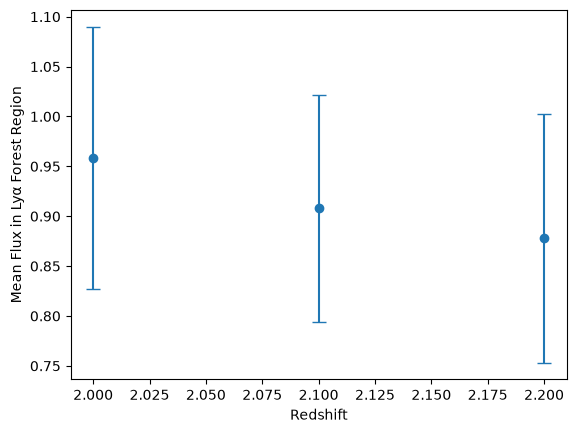

In [16]:
plt.errorbar(redshifts, mean_fluxes, yerr=mean_fluxes_err, fmt='o', capsize=5)
plt.xlabel('Redshift')
plt.ylabel('Mean Flux in Lyα Forest Region')

plt.show()

In [5]:
resid_file = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/SDSS_support_files/residcorr_v5_4_45.dat"
resid = []
resid_lam = []

with open(resid_file) as rfile:
    reader = csv.reader(rfile, delimiter=" ")
    for i, row in enumerate(reader):
        if i != 0:
            resid.append(float(row[-1]))
            resid_lam.append(float(row[1]))

resid_lam_file = np.array(resid_lam)
resid_file = np.array(resid)

print(10**resid_lam_file)
print(resid_file)

[ 3544.86744474  3545.68377461  3546.50029247 ... 10408.78408917
 10411.18107623 10413.57861528]
[0.665556 0.665556 0.859479 ... 1.04152  1.04152  1.04152 ]


In [7]:
def load_spectra_cache(path):
    """Load a spectra cache saved by build_and_save_spectra. Returns a dict of arrays."""
    with np.load(path) as npz:
        return {
            "wavelength": npz["wavelength"],
            "flux": npz["flux"],
            "mask": npz["mask"],
            "snr": npz["snr"],
            "redshift": npz["redshift"],
            "pmf": npz["pmf"],
            "valid_spectrum": npz["valid_spectrum"],
            "z_min": float(npz["z_min"]),
            "z_max": float(npz["z_max"]),
        }

In [33]:
out_file_path = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/SDSS_spectra/SDSS_support_files/spectra_cache.npz"

data = load_spectra_cache(out_file_path)

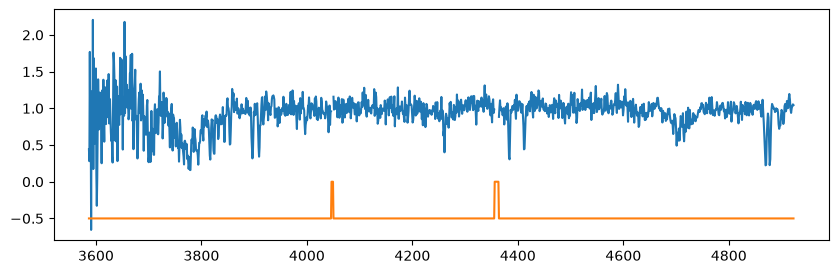

In [34]:
fig = plt.figure(figsize=(10, 3))

plt.plot(data["wavelength"], data["flux"][0])
plt.plot(data["wavelength"], [-0.5 if x else 0 for x in data["mask"][0]])

In [32]:
print(data["z_max"])

3.05
